In [ ]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
import warnings

warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
from utils import plot_iqr_boxplot, show_target_by_category, plot_histogram, full_stats, plot_target_rate_by_bins, plot_target_correlation, plot_mutual_information, plot_feature_correlation_heatmap

df = pd.read_csv('../data/loan_data_new.csv')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# №1 Знакомство с датасетом

In [ ]:
df.head()

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


In [ ]:
# Смотрим общую информацию, пропуски и статистику
print("\nРазмер данных:", df.shape, "\n")
df.info()
display(df.describe())


Размер данных: (45000, 14) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  45000 non-null  int64  
 1   Gender               45000 non-null  object 
 2   Education            45000 non-null  object 
 3   Person Income        45000 non-null  int64  
 4   Employee Experience  45000 non-null  int64  
 5   Home Onwership       45000 non-null  object 
 6   Loan Amount          45000 non-null  int64  
 7   Loan Intent          45000 non-null  object 
 8   Loan interest Rate   45000 non-null  float64
 9   Loan percentage      45000 non-null  float64
 10  Credit History       45000 non-null  int64  
 11  Credit Score         45000 non-null  int64  
 12  Previous Loan        45000 non-null  object 
 13  Loan Status          45000 non-null  int64  
dtypes: float64(2), int64(7), object(5)
memory usage: 4.8+ MB

,Age,Person Income,Employee Experience,Loan Amount,Loan interest Rate,Loan percentage,Credit History,Credit Score,Loan Status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [ ]:
full_stats(df)

,Age,Person Income,Employee Experience,Loan Amount,Loan interest Rate,Loan percentage,Credit History,Credit Score,Loan Status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
unique,60.000000,3.398900e+04,63.000000,4483.000000,1302.000000,64.000000,29.000000,340.000000,2.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
median,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000
Q1,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
Q3,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
IQR,6.000000,4.858525e+04,7.000000,7237.250000,4.400000,0.120000,5.000000,69.000000,0.000000


In [ ]:
#Проверяем баланс классов
print("Количество по классам:")
print(df["Loan Status"].value_counts())

print("\nДоли:")
print((df["Loan Status"].value_counts(normalize=True) * 100).round(1))
#Отсюда виден дизбаланс классов, это значит что нам нужно будет это чинить


Количество по классам:
Loan Status
0    35000
1    10000
Name: count, dtype: int64

Доли:
Loan Status
0    77.8
1    22.2
Name: proportion, dtype: float64


In [ ]:
#Все признаки в датасете
features = [c for c in df.columns if c != "Loan Status"]
print("Признаки:", features)
print("\nЧисло признаков:", len(features))

Признаки: ['Age', 'Gender', 'Education', 'Person Income', 'Employee Experience', 'Home Onwership', 'Loan Amount', 'Loan Intent', 'Loan interest Rate', 'Loan percentage', 'Credit History', 'Credit Score', 'Previous Loan']

Число признаков: 13


> ## **Выводы по первичному осмотру**:
> 1. **Объем**: 45 000 строк и 14 колонок.
> 2. **Пропуски**: В данных нет отсутствующих значений `(NaN)`.
> 3. **Аномалии**: В статистике `Age` максимальное значение — 144 года, а в `Employee Experience` — 125 лет.
> 4. **Решение**: В следующем этапе очистим данные.




# №2 Здоровье данных

In [ ]:
print("Отсутствующих значений:", df.isna().sum().sum())
print("Полных дубликатов:", df.duplicated().sum())

Отсутствующих значений: 0
Полных дубликатов: 0


In [ ]:
# разделим признаки на числовые и категориальные
numeric = df.select_dtypes(include=np.number).columns.tolist()
categorical = df.select_dtypes(exclude=np.number).columns.tolist()

# целевую убираем из признаков
target = "Loan Status"
numeric = [c for c in numeric if c != target]

print("\nЧисловые признаки:", numeric)
print("Категориальные:", categorical)
print("Целевая:", target)


Числовые признаки: ['Age', 'Person Income', 'Employee Experience', 'Loan Amount', 'Loan interest Rate', 'Loan percentage', 'Credit History', 'Credit Score']
Категориальные: ['Gender', 'Education', 'Home Onwership', 'Loan Intent', 'Previous Loan']
Целевая: Loan Status


In [ ]:
#скрытые дубликаты
print("Проверяем есть ли скрытые дубликаты\n")

for col in categorical:
    print(f"{col}:", df[col].nunique())

print()
for col in categorical:
    print(f"{col}:", df[col].unique())

print("\nСкрытых дубликатов не обнаружено")

Проверяем есть ли скрытые дубликаты

Gender: 2
Education: 5
Home Onwership: 4
Loan Intent: 6
Previous Loan: 2

Gender: ['female' 'male']
Education: ['Master' 'High School' 'Bachelor' 'Associate' 'Doctorate']
Home Onwership: ['RENT' 'OWN' 'MORTGAGE' 'OTHER']
Loan Intent: ['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']
Previous Loan: ['No' 'Yes']

Скрытых дубликатов не обнаружено


In [ ]:
print("Проверяем есть ли скрытые категории\n")

for col in numeric:
    print(f"{col}:", df[col].nunique())


print("\nСкрытых категорий не обнаружено")

Проверяем есть ли скрытые категории

Age: 60
Person Income: 33989
Employee Experience: 63
Loan Amount: 4483
Loan interest Rate: 1302
Loan percentage: 64
Credit History: 29
Credit Score: 340

Скрытых категорий не обнаружено


In [ ]:
import pandas as pd

#Теперь проверяем выбросы
def count_outliers_iqr(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lo) | (series > hi)).sum()

print("Выбросы по числовым признакам:")
for col in numeric:
    n_out = count_outliers_iqr(df[col])
    print(f"  {col}: {n_out} выбросов")


Выбросы по числовым признакам:
  Age: 2188 выбросов
  Person Income: 2218 выбросов
  Employee Experience: 1724 выбросов
  Loan Amount: 2348 выбросов
  Loan interest Rate: 124 выбросов
  Loan percentage: 744 выбросов
  Credit History: 1366 выбросов
  Credit Score: 467 выбросов


In [ ]:
#Фильтруем физически невозможные записи
clean_df = df[(df['Age'] <= 80) & (df['Employee Experience'] <= 60)].copy()

print(f"Было строк в исходном датасете: {len(df)}")
print(f"Стало строк после очистки аномалий: {len(clean_df)}")
print(f"Удалено реальных ошибок: {len(df) - len(clean_df)}")

Было строк в исходном датасете: 45000
Стало строк после очистки аномалий: 44990
Удалено реальных ошибок: 10


> **Вывод по анализу выбросов:**
> 1. **Аномалии:** Из 45 000 строк удалено всего 10 фейковых записей - `Age > 80` и `Employee Experience > 60`.
> 2. **Финансовые показатели:** Выбросы по IQR в `Person Income`, `Loan Amount`, `Credit History` и др. **сохранены полностью**, так как отражают реальное финансовое разнообразие клиентов.

# №3 Распределения и связь с целевой

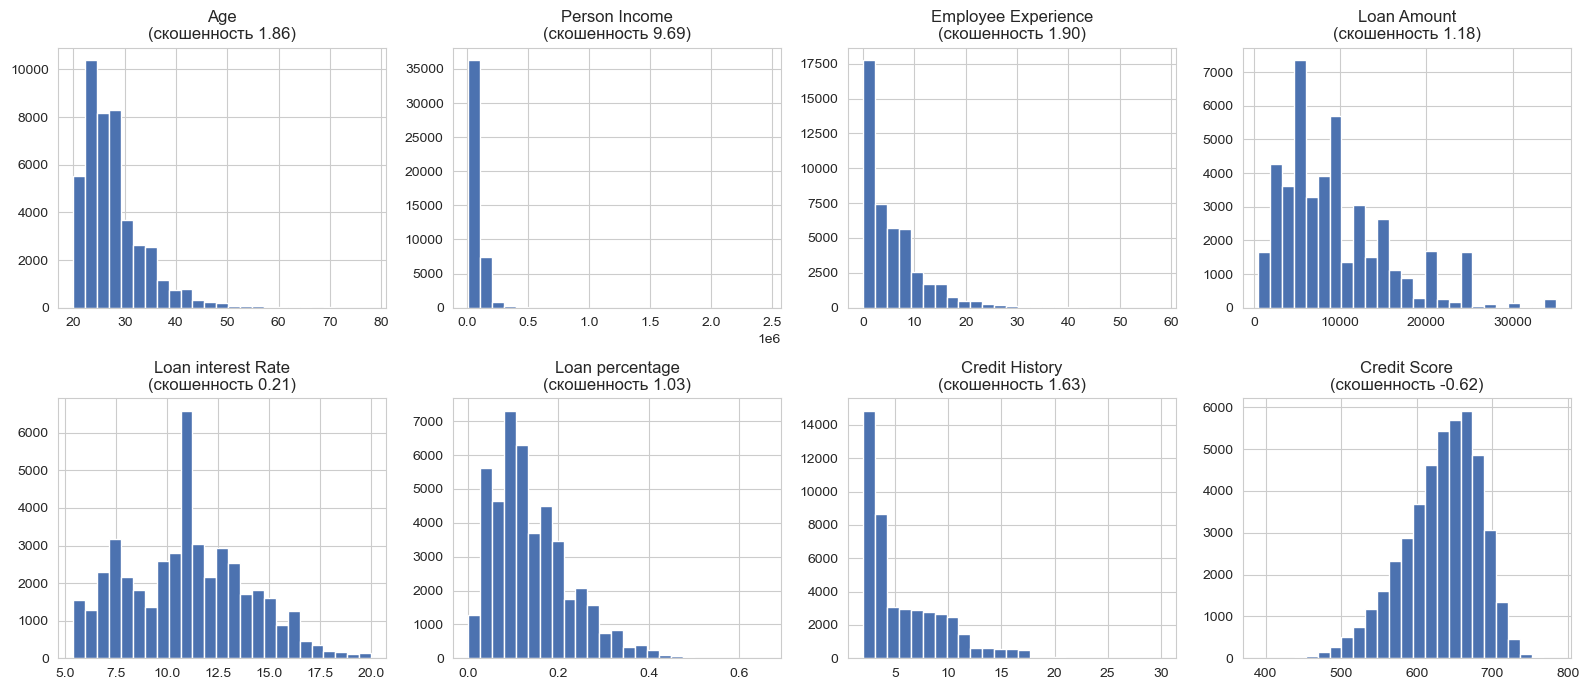

Скошенность:
Age: 1.86
Person Income: 9.69
Employee Experience: 1.9
Loan Amount: 1.18
Loan interest Rate: 0.21
Loan percentage: 1.03
Credit History: 1.63
Credit Score: -0.62


In [ ]:
import matplotlib.pyplot as plt

# гистограммы всех числовых признаков
fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for ax, col in zip(axes.flatten(), numeric):
    ax.hist(clean_df[col].dropna(), bins=25, color="#4C72B0", edgecolor="white")
    ax.set_title(f"{col}\n(скошенность {clean_df[col].skew():.2f})")

plt.tight_layout()
plt.show()

print("Скошенность:")
for col in numeric:
    print(clean_df[col].name, ": ", clean_df[col].skew().round(2), sep="")




Максимальная зарплата:  2448661 



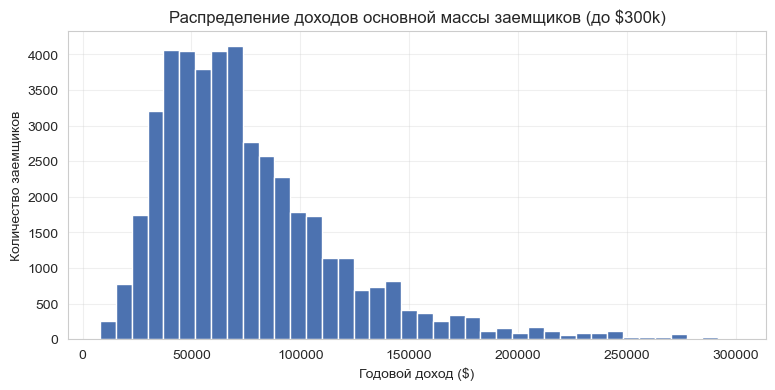

Показано на графике: 44630 из 44990 заемщиков.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

print("\nМаксимальная зарплата: ", clean_df["Person Income"].max(), "\n") #Такие высокие зарплаты мешают увидеть настоящий график

# Берем для графика людей с доходом до $300,000 (это 99.8% всех данных)
income_normal = clean_df[clean_df['Person Income'] <= 300000]['Person Income']

plt.figure(figsize=(9, 4))
plt.hist(income_normal, bins=40, color="#4C72B0", edgecolor="white")

plt.title("Распределение доходов основной массы заемщиков (до $300k)")
plt.xlabel("Годовой доход ($)")
plt.ylabel("Количество заемщиков")
plt.grid(alpha=0.3)
plt.show()

print(f"Показано на графике: {len(income_normal)} из {len(clean_df)} заемщиков.")

In [ ]:
import pandas as pd

# средние числовых признаков по классам целевой
print("Средние признаков по Loan Status (0=одобрен, 1=отклонен):")
print(clean_df.groupby("Loan Status")[numeric].mean().round(1))

Средние признаков по Loan Status (0=отклонен, 1=одобрен):
              Age  Person Income  Employee Experience  Loan Amount  \
Loan Status                                                          
0            27.8        85631.3                  5.5       9219.7   
1            27.5        59886.1                  5.2      10855.7   

             Loan interest Rate  Loan percentage  Credit History  Credit Score  
Loan Status                                                                     
0                          10.5              0.1             5.9         632.8  
1                          12.9              0.2             5.8         631.9  


In [ ]:
print("Проверяем датасет вместе с медианой(Виден дизбаланс в колонке Person Income)")
clean_df.groupby('Loan Status')[numeric].agg(['mean', 'median']).round(1)

Проверяем датасет вместе с медианой(Виден дизбаланс в колонке Person Income)


Age        Person Income          Employee Experience         \
             mean median          mean   median                mean median   
Loan Status                                                                  
0            27.8   26.0       85631.3  72926.0                 5.5    4.0   
1            27.5   26.0       59886.1  50629.0                 5.2    3.0   

            Loan Amount         Loan interest Rate        Loan percentage  \
                   mean  median               mean median            mean   
Loan Status                                                                 
0                9219.7  8000.0               10.5   10.8             0.1   
1               10855.7  9750.0               12.9   13.0             0.2   

                   Credit History        Credit Score         
            median           mean median         mean median  
Loan Status                                                   
0              0.1            5.9    4.0        632.8  640.0  
1              0.2            5.8    4.0        631.9  639.0

In [ ]:
# частоты категориальных данных
print("Категориальные признаки:")
for col in categorical:
    print((clean_df[col].value_counts(normalize=True) * 100).round(1))

Категориальные признаки:
Gender
male      55.2
female    44.8
Name: proportion, dtype: float64
Education
Bachelor       29.8
Associate      26.7
High School    26.6
Master         15.5
Doctorate       1.4
Name: proportion, dtype: float64
Home Onwership
RENT        52.1
MORTGAGE    41.1
OWN          6.6
OTHER        0.3
Name: proportion, dtype: float64
Loan Intent
EDUCATION            20.3
MEDICAL              19.0
VENTURE              17.4
PERSONAL             16.8
DEBTCONSOLIDATION    15.9
HOMEIMPROVEMENT      10.6
Name: proportion, dtype: float64
Previous Loan
Yes    50.8
No     49.2
Name: proportion, dtype: float64


In [ ]:
clean_df = clean_df.rename(columns={"Loan Status": "Is Rejected"})

clean_df = clean_df.rename(columns={"Home Onwership": "Home Ownership"})

# Проверяем, что название изменилось
print(clean_df.columns)

Index(['Age', 'Gender', 'Education', 'Person Income', 'Employee Experience',
       'Home Ownership', 'Loan Amount', 'Loan Intent', 'Loan interest Rate',
       'Loan percentage', 'Credit History', 'Credit Score', 'Previous Loan',
       'Is Rejected'],
      dtype='object')


> ### 📌 Корректировка и стандартизация наименований признаков
>
> Для повышения интерпретируемости данных и устранения неоднозначности в коде были выполнены следующие преобразования:
>
> 1. **Переименование целевой переменной (`Loan Status` → `Is Rejected`):**
>    В исходном датасете значение `1` соответствует **отказу** в выдаче кредита, а `0` — **одобрению** (что противоположно стандартному кодированию `Loan Status`, где `1` обычно обозначает одобрение). Чтобы избежать путаницы при интерпретации графиков и метрик качества, переменная переименована в `Is Rejected`. Теперь флаг `1` прямо указывает на наступление целевого события (*Отказ = True*).
>
> 2. **Исправление орфографической ошибки (`Home Onwership` → `Home Ownership`):**
>    Наименование колонки приведено к грамматически корректному виду для соблюдения стандартов чистоты кода.


#### Is Rejected = 1 — заявка отклонена, 0 — одобрена

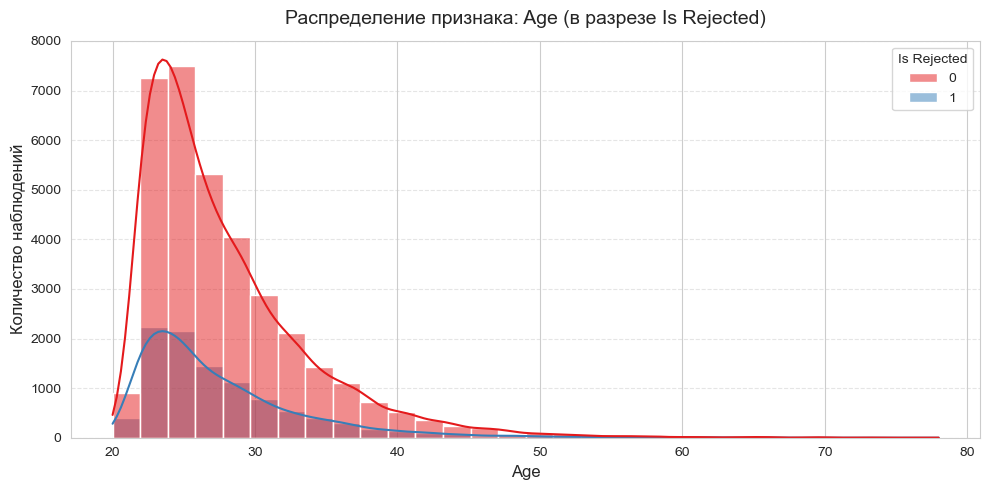

In [ ]:
plot_histogram(clean_df, column='Age', hue='Is Rejected')



> ### 📌 Признак: `Age` (Возраст заёмщика)
>
> * **Форма графика:** Выраженное асимметричное распределение с длинным правым хвостом (*right-skewed*). Пик заявок сосредоточен в диапазоне **23–30 лет** (более 24 000 человек из 45 000), после чего число заёмщиков плавно спадает к 40–50 годам, уходя в единичные наблюдения к 60–70 годам.
> * **Связь с таргетом:** Соотношение одобрений и отказов остаётся стабильным на всём возрастном спектре — около **70–80% одобрений** и **20–30% отказов**. Это соотношение сохраняется как в основной группе 23–30 лет (~6 500 отказов на 24 000 заявок), так и среди других возрастов.
> * **Бизнес-вывод / Гипотеза:** Возраст определяет объём входящего потока клиентов (молодые люди запрашивают кредиты чаще всего), но практически не меняет относительную вероятность одобрения. В изоляции признак имеет низкую предсказательную способность для рисков.

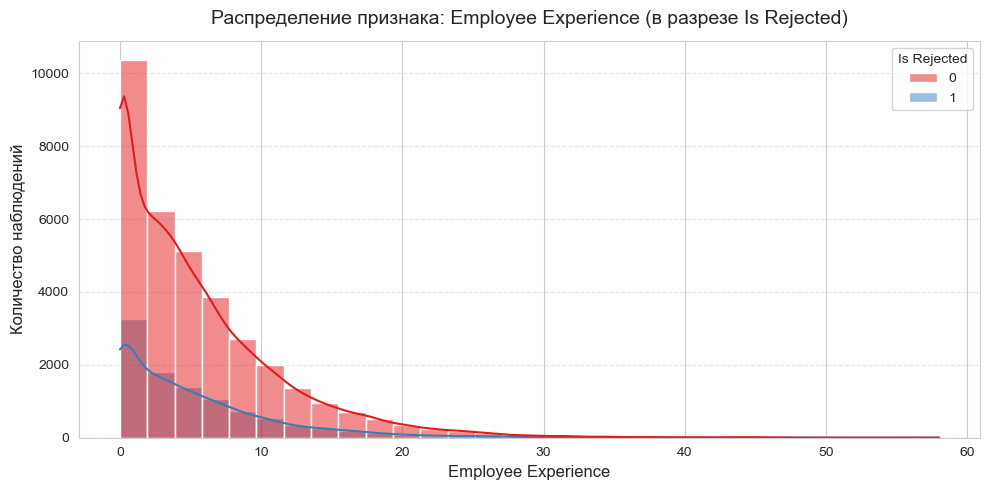

In [ ]:
plot_histogram(clean_df, column='Employee Experience', hue='Is Rejected')

> ### 📌 Признак: `Employee Experience` (Опыт работы / стаж)
>
> * **Форма графика:** Сильно скошенное вправо распределение (*right-skewed*). Максимальная концентрация заёмщиков наблюдается в категории с минимальным стажем: **0–2 года** (около 10 000 человек). По мере увеличения стажа объём заявок плавно и непрерывно снижается: 6 000 человек в категории 2–4 года, 5 000 человек — в категории 4–8 лет, экспоненциально уменьшаясь для опытных сотрудников.
> * **Связь с таргетом:** Соотношение одобрений и отказов сохраняет пропорцию на всём протяжении графика. В группе с минимальным опытом (0–2 года) из 10 000 человек отказ получают ~3 400 заёмщиков (~34%), в категории 2–4 года из 6 000 человек отклонены ~1 800 (~30%), а при стаже 4–8 лет — ~1 500 отказов на 5 000 заявок (~30%).
> * **Бизнес-вывод / Гипотеза:** Как и в случае с возрастом, стаж определяет **объём входящей воронки** (люди с небольшим опытом обращаются за кредитами чаще всего). Относительный риск дефолта/отказа при этом снижается незначительно, поэтому сам по себе стаж в изоляции обладает умеренной предсказательной силой и требует рассмотрения в связке с доходом (`Person Income`).  Так же стоит упомянуть что 21% заёмщиков имеют 0 лет опыта работы. Возможно это вчерашние студенты или только что устроившееся на работу люди.

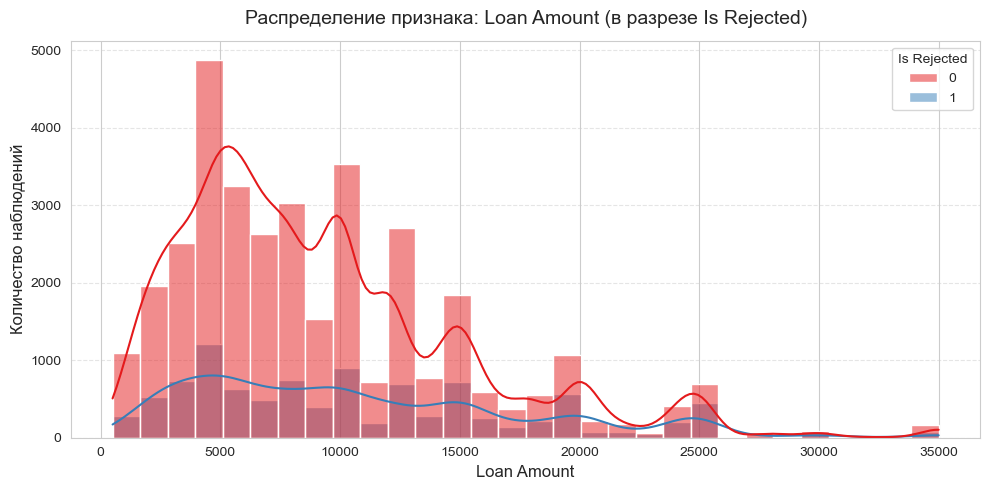

In [ ]:
plot_histogram(clean_df, column='Loan Amount', hue='Is Rejected')

> ### 📌 Признак: `Loan Amount` (Запрашиваемая сумма кредита)
>
> * **Форма графика:** Полимодальное («зубчатое») распределение с выраженными пиками на «круглых» суммах. Главный глобальный пик находится в районе **$5 000** (~5 000 заёмщиков). Затем наблюдаются резкие локальные всплески на знаках **$10 000** (~3 500 заёмщиков), **$12 000–13 000** (~2 500 заёмщиков) и около **$15 000** (~2 000 заёмщиков) с глубокими провалами (до 600–800 заёмщиков) в промежуточных некруглых значениях.
> * **Связь с таргетом:** Доля отказов распределена по графику неравномерно: на небольших суммах (в районе первого пика на $5 000) абсолютное большинство заемщиков получает одобрение. Однако по мере смещения к крупным пикам ($10 000, $15 000 и выше) плотность отказанной группы визуально возрастает, так как большие суммы представляют для банка больший финансовый риск.
> * **Бизнес-вывод / Гипотеза:** В данных чётко проявляется психологический фактор заёмщиков — психологический выбор «круглых» сумм при оформлении заявки. Абсолютная сумма кредита напрямую коррелирует с риском: чем больше запрашиваемый лимит, тем выше требования скоринга и вероятность отказа, однако ключевую роль играет не сама сумма, а её отношение к доходу (`Loan percentage`).

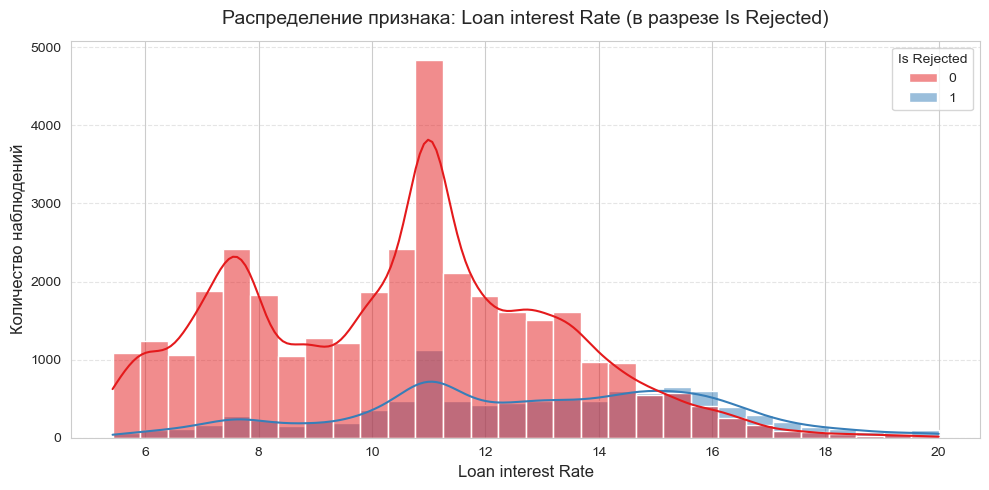

In [ ]:
plot_histogram(clean_df, column='Loan interest Rate', hue='Is Rejected')

> ### 📌 Признак: `Loan interest Rate` (Процентная ставка по кредиту)
>
> * **Форма графика:** Бимодальное (двухпиковое) распределение. Первый локальный пик находится на уровне **7.5%** (~2 500 заёмщиков), а главный глобальный пик — на **11%** (~5 000 заёмщиков). Вокруг пиков наблюдается плавный рост, в то время как на остальных участках объём сохраняется на уровне ~1 000 человек.
> * **Связь с таргетом:** Наблюдается чёткая прямая корреляция между ростом процентной ставки и ростом доли отказов. При низкой ставке (**6%**) отказы минимальны; при **10%** их доля ощутимо возрастает, а в зоне высоких ставок (**15% и выше**) число отказов становится больше, чем число одобрений.
> * **Бизнес-вывод / Гипотеза:** График идеально отражает банковское риск-ориентированное ценообразование (*risk-based pricing*): высокорисковым клиентам система автоматически предлагает более высокую ставку, что в итоге приводит к частым отказам. Два пика обусловлены разделением клиентов на «льготный/надёжный» и «массовый» сегменты. Признак обладает высочайшей предсказательной силой.

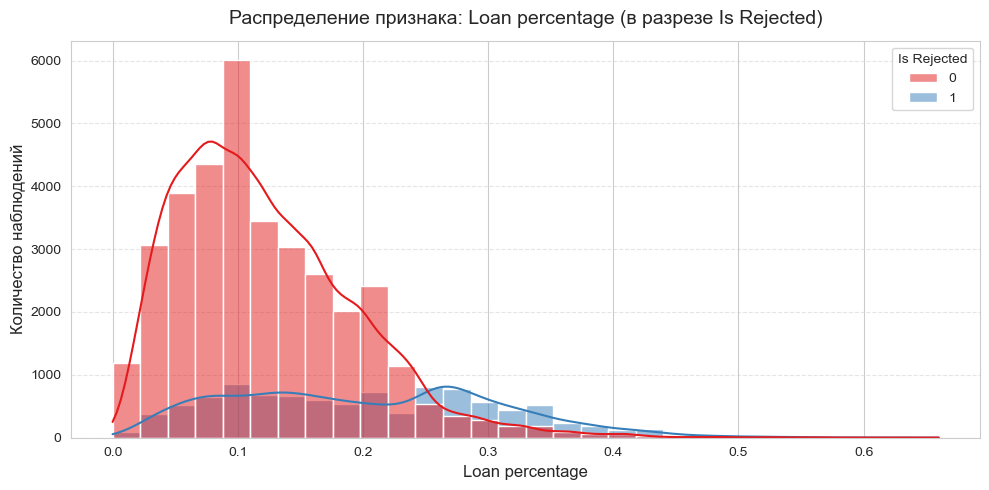

In [ ]:
plot_histogram(clean_df, column='Loan percentage', hue='Is Rejected')

> ### 📌 Признак: `Loan percentage` / `loan_percent_income` (Доля кредита от дохода)
>
> * **Форма графика:** Выраженное асимметричное распределение с длинным правым хвостом (*right-skewed*). Диапазон значений варьируется от 0.0 до 0.6–0.7, а главный пик концентрации заявлений находится в районе **0.1 (10% от дохода)**. От 0.0 до 0.1 идёт плавное увеличение количества заёмщиков, после чего наблюдается постепенное снижение с длинным хвостом вправо.
> * **Связь с таргетом:** Наблюдается прямая и очень жесткая зависимость с отказом. При низких значениях (около 0.0–0.1) доля одобрений максимальна. Однако по мере роста доли кредита относительно дохода процент отказов быстро возрастает, и уже в районе **0.25 (25% от дохода)** количество отказов превышает количество одобрений.
> * **Бизнес-вывод / Гипотеза:** Признак является прямым аналогом коэффициента долговой нагрузки (*Debt-to-Income / DTI*). Вывод в том что если запрашиваемый кредит превышает 20–25% от годового дохода клиента, риск дефолта считается неприемлемым, и система начинает массово отклонять заявки. Один из ключевых факторов для модели.

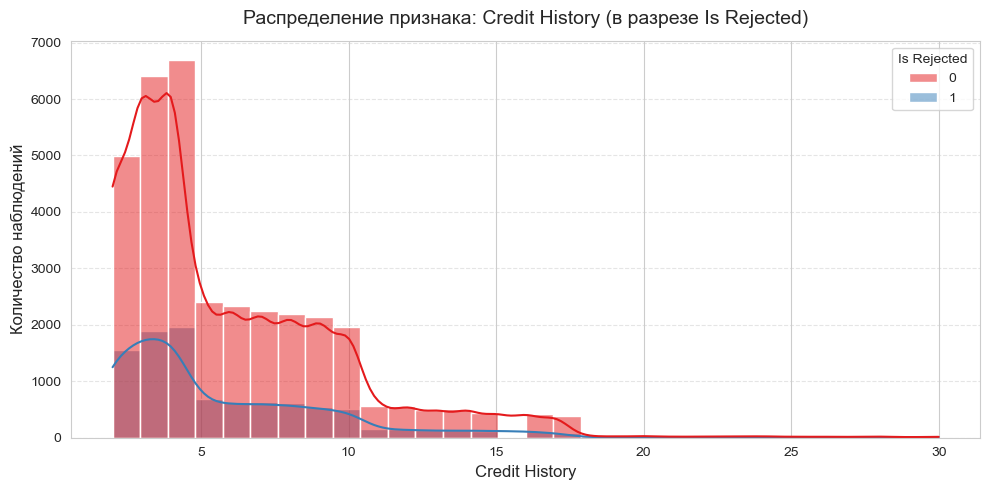

In [ ]:
plot_histogram(clean_df, column='Credit History', hue='Is Rejected')

> ### 📌 Признак: `Credit History` / `cb_person_cred_hist_length` (Длительность кредитной истории)
>
> * **Форма графика:** Дискретное ступенчатое распределение с несколькими выраженными шагами спада. Основной массив заёмщиков сосредоточен в диапазоне **0–5 лет**. После 5 лет происходит резкое падение количества наблюдений примерно в 2.5 раза (диапазон 6–10 лет), после чего следует ещё один спад в 2.5 раза (10–15 лет). В районе 15–16 лет данные практически отсутствуют, а на отметках 17–18 лет наблюдаются небольшие локальные всплески.
> * **Связь с таргетом:** Соотношение одобрений и отказов сохраняется стабильным и практически одинаковым на всех отрезках графика. Процент отказов не меняется в зависимости от того, имеет ли заёмщик короткую кредитную историю (0–5 лет) или многолетнюю (10+ лет).
> * **Бизнес-вывод / Гипотеза:** Сам по себе стаж владения кредитной историей не служит для банка критерием фильтрации рисков (длинная история не гарантирует автоматического одобрения, а короткая не ведет к отказу). Признак является дискретным с небольшим числом уникальных значений и в изоляции обладает низкой предсказательной силой, но может быть полезен для проверки логической согласованности с возрастом (`Age`).

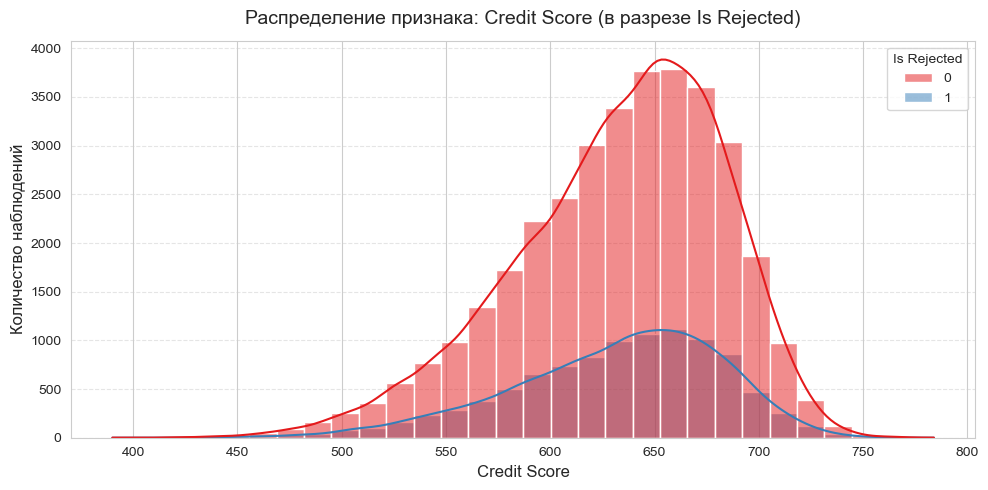

In [ ]:
plot_histogram(clean_df, column='Credit Score', hue='Is Rejected')

> ### 📌 Признак: `Credit Score` (Кредитный рейтинг заёмщика)
>
> * **Форма графика:** Симметричное колоколообразное распределение (близкое к гауссову/нормальному) с невеликой отрицательной скошенностью (*left-skewed*, skewness = -0.61). Основная масса заёмщиков сконцентрирована в среднем диапазоне рейтинговых баллов (около 600–670), а левый хвост плавно уходит в сторону низких значений.
> * **Связь с таргетом:** Соотношение одобрений и отказов остаётся стабильным на всём спектре значений кредитного рейтинга. Визуально доля отклоненных заявок сохраняет одинаковую пропорцию как среди клиентов с низкими баллами, так и среди заёмщиков с высоким скорингом.
> * **Бизнес-вывод / Гипотеза:** В изоляции базовый кредитный рейтинг в данном датасете не показывает прямой монотонной связи со статусом одобрения. Это говорит о том, что банковская система принимает решение не на основе одного лишь итогового балла, а опирается на более специфичные финансовые метрики (`Loan percentage`, `Loan interest Rate`, `Previous Loan`).

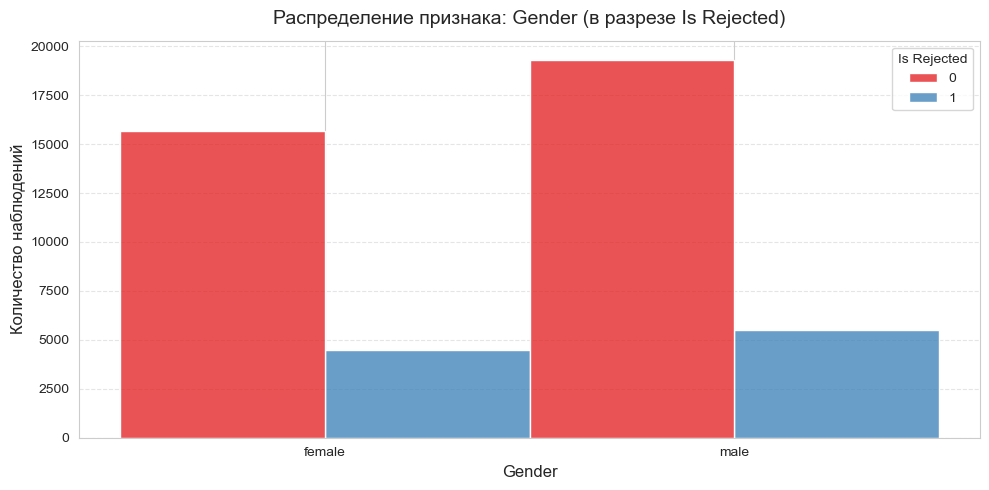

In [ ]:
plot_histogram(clean_df, column='Gender', hue='Is Rejected', kde=False, multiple='dodge')

In [ ]:
show_target_by_category(clean_df, "Gender")

🔹 Признак: 'Gender' (соотношение 'Is Rejected' в %):



Is Rejected,0,1
Gender,,
female,77.7,22.3
male,77.8,22.2


> ### 📌 Признак: `Gender` / `person_gender` (Пол заёмщика)
>
> * **Форма графика:** Категориальный признак с бинарным распределением. Категории распределены относительно равномерно без сильного дисбаланса классов.
> * **Связь с таргетом:** Соотношение одобрений и отказов абсолютно одинаково для обеих групп. Процент одобрений и отказов у мужчин полностью совпадает с аналогичным показателем у женщин.
> * **Бизнес-вывод / Гипотеза:** Пол заёмщика не оказывает совершенно никакого влияния на итоговое решение по кредиту. Это полностью соответствует правилам этичного банковского скоринга и законодательным нормам, запрещающим дискриминацию по полу. Признак не имеет предсказательной силы в изоляции и является кандидатом на удаление при отборе фичей.

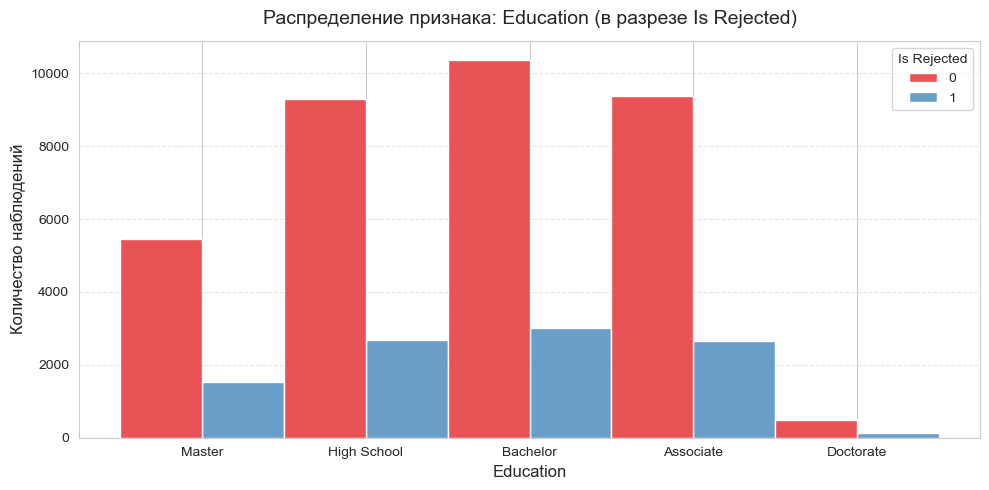

In [ ]:
plot_histogram(clean_df, column='Education', hue='Is Rejected', kde=False, multiple='dodge')

In [ ]:
show_target_by_category(clean_df, "Education")

🔹 Признак: 'Education' (соотношение 'Is Rejected' в %):



Is Rejected,0,1
Education,,
Associate,78.0,22.0
Bachelor,77.5,22.5
Doctorate,77.1,22.9
High School,77.7,22.3
Master,78.2,21.8


> ### 📌 Признак: `Education Level` / `person_education` (Уровень образования)
>
> * **Форма графика:** Категориальный признак с 5 уровнями. Основную массу клиентов составляют заёмщики со степенями **Bachelor**, **High School** и **Associate**. Категория **Master** встречается примерно в два раза реже, а обладателей степени **Doctorate** в датасете совсем мало.
> * **Связь с таргетом:** Пропорция одобрений и отказов абсолютно одинакова для всех категорий образования — наличие ученой степени или только школьного аттестата не меняет относительную вероятность получения кредита.
> * **Бизнес-вывод / Гипотеза:** Само по себе формальное образование не является для банка прямым критерием оценки риска. Его гипотетическое влияние на платежеспособность уже заложено в признаке дохода (`Person Income`). В изоляции признак имеет практически нулевую предсказательную силу.

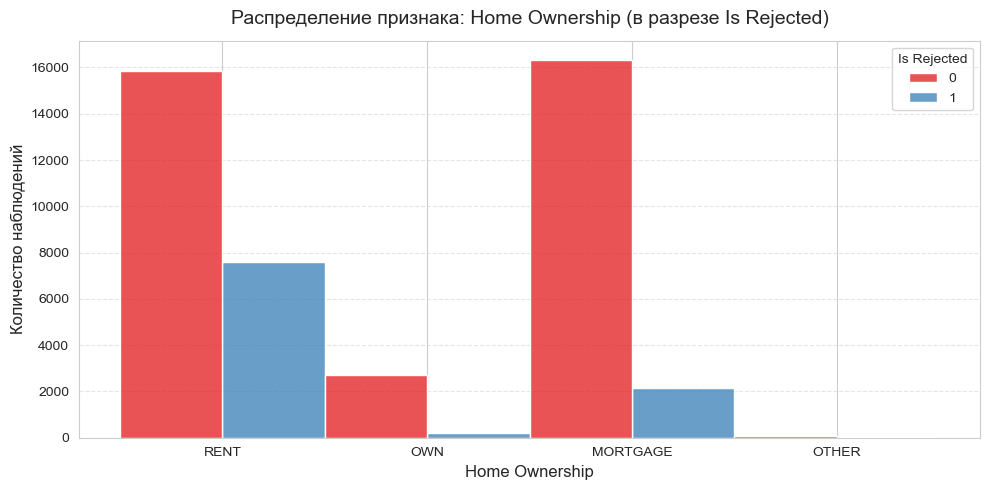

In [ ]:
plot_histogram(clean_df, column='Home Ownership', hue='Is Rejected', kde=False, multiple='dodge')

In [ ]:
show_target_by_category(clean_df, "Home Ownership")

🔹 Признак: 'Home Ownership' (соотношение 'Is Rejected' в %):



Is Rejected,0,1
Home Ownership,,
MORTGAGE,88.4,11.6
OTHER,66.7,33.3
OWN,92.5,7.5
RENT,67.6,32.4


> ### 📌 Признак: `Home Ownership` / `person_home_ownership` (Тип владения жильём)
>
> * **Форма графика:** Категориальный признак с 4 группами. Подавляющая масса заёмщиков распределена между арендаторами (**rent**) и клиентами с ипотекой (**mortgage**). Собственниками жилья (**own**) являются лишь малая часть, а категория **other** имеет исчезающе малый объём.
> * **Связь с таргетом:** Наблюдается сильнейшая зависимость с одобрением! При равном количестве одобрений (~16 000) в группе арендаторов (**rent**) зафиксировано колоссальное количество отказов — **~8 000 человек (~33%)**. У ипотечников (**mortgage**) при тех же 16 000 одобрений отказов всего **~2 000 (~11%)**, у собственников жилья (**own**) доля отказов тоже очень низкая.
> * **Бизнес-вывод / Гипотеза:** Статус жилья — один из сильнейших факторов скоринга. Собственная недвижимость или действующая ипотека (подтверждающая прошлую проверку надежности другим банком) служат для риска мощнейшим маркером стабильности. Аренда же воспринимается банком как фактор повышенного риска. Признак имеет высочайшую предсказательную способность.

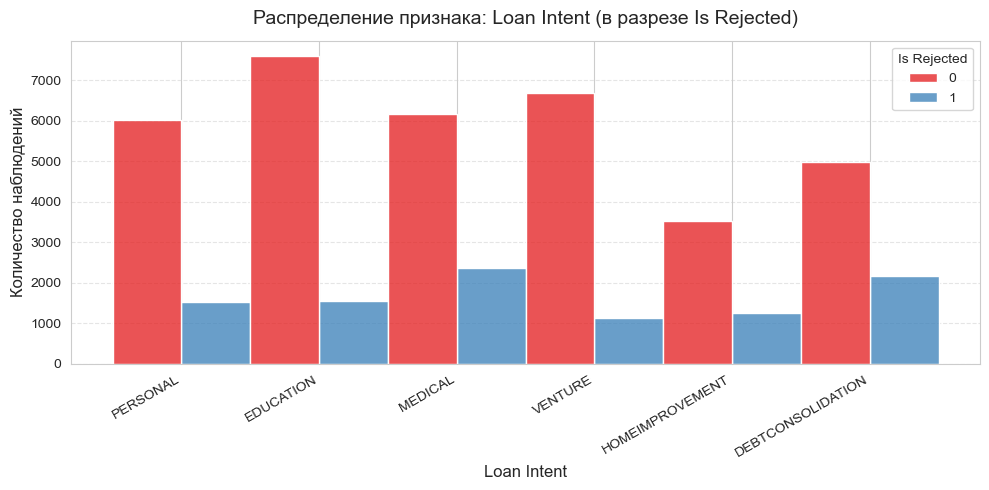

In [ ]:
plot_histogram(clean_df, column='Loan Intent', hue='Is Rejected', kde=False, multiple='dodge', rotation=30)

In [ ]:
show_target_by_category(clean_df, "Loan Intent")

🔹 Признак: 'Loan Intent' (соотношение 'Is Rejected' в %):



Is Rejected,0,1
Loan Intent,,
DEBTCONSOLIDATION,69.7,30.3
EDUCATION,83.0,17.0
HOMEIMPROVEMENT,73.7,26.3
MEDICAL,72.2,27.8
PERSONAL,79.9,20.1
VENTURE,85.6,14.4


> ### 📌 Признак: `Loan Intent` / `loan_intent` (Цель кредита)
>
> * **Форма графика:** Категориальный признак с 6 классами без сильного дисбаланса. Среди одобренных заявок лидирует категория **Education**, за ней идут **Venture**, **Personal** и **Medical**. Замыкают список **Debt Consolidation** и **Home Improvement**.
> * **Связь с таргетом:** Процент отказов заметно различается в зависимости от цели кредита. Наивысшую конверсию в одобрение показывают **Venture** (85% одобрений / 15% отказов) и **Education** (83% / 17%), за ними идет **Personal** (80% / 20%). Более высокий уровень риска демонстрируют цели **Home Improvement** (73% / 26%), **Medical** (72% / 27%) и **Debt Consolidation** (70% / 30%).
> * **Бизнес-вывод / Гипотеза:** Назначение кредита служит прямым маркёром финансовой дисциплины и риска. Вложения в образование и бизнес (Venture) банк расценивает как инвестиции с высокой возвратностью, в то время как рефинансирование существующих долгов (Debt Consolidation) и незапланированные медицинские расходы указывают на финансовые сложности заёмщика, что приводит к росту отказов до 30%. Признак обладает высокой предсказательной силой.

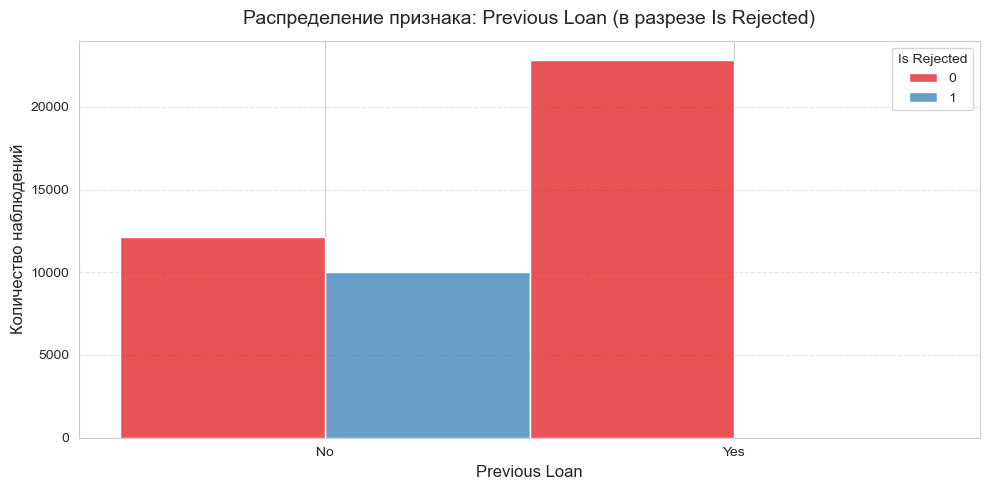

In [ ]:
plot_histogram(clean_df, column='Previous Loan', hue='Is Rejected', kde=False, multiple='dodge')

In [ ]:
show_target_by_category(clean_df, "Previous Loan")

🔹 Признак: 'Previous Loan' (соотношение 'Is Rejected' в %):



Is Rejected,0,1
Previous Loan,,
No,54.8,45.2
Yes,100.0,0.0


> ### 📌 Признак: `Previous Loan`(Наличие прошлых кредитов) ОЧЕНЬ ВАЖНО!
>
> * **Форма графика:** Бинарный категориальный признак (`Yes` / `No`). Категория заёмщиков с прошлыми займами (**Yes**) составляет преимущественную часть датасета (~25 000 человек).
> * **Связь с таргетом:** Демонстрирует детерминированное разделение классов. Для категории **Yes** процент одобрения составляет **100%** (0% отказов). У заёмщиков без истории прошлых займов (**No**) одобрение составляет только **55%**, а доля отказов достигает **45%**. 
> * **Бизнес-вывод / Гипотеза:** Успешный опыт прошлого кредитования служит для банка главным индикатором надежности. Наличие закрытых прошлых кредитов гарантирует автоматическое одобрение, тогда как для новых заёмщиков вероятность отказа возрастает до уровня подбрасывания монетки. Это огромная проблема для будущей модели. Потенциальное target leakage / искусственный shortcut. В реальной жизни ни один банк не одобрит абсолютно всем кредиты у кого до этого была кредитная история. Мы вернемся к этому признаку далее в пункте №4.


Максимальная зарплата:  2448661 



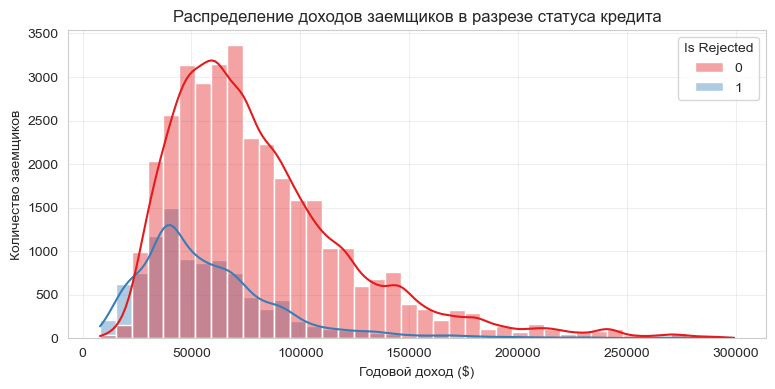

Показано на графике: 44630 из 44990 заемщиков.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

print("\nМаксимальная зарплата: ", clean_df["Person Income"].max(), "\n")

# Фильтруем весь датафрейм, чтобы сохранить связь с целевой переменной
income_normal = clean_df[clean_df["Person Income"] <= 300000]

plt.figure(figsize=(9, 4))
sns.histplot(
    data=income_normal,
    x="Person Income",
    hue="Is Rejected",
    bins=40,
    kde=True,
    palette="Set1",
    alpha=0.4,
)

plt.title("Распределение доходов заемщиков в разрезе статуса кредита")
plt.xlabel("Годовой доход ($)")
plt.ylabel("Количество заемщиков")
plt.grid(alpha=0.3)
plt.show()

print(
    f"Показано на графике: {len(income_normal)} из {len(clean_df)} заемщиков."
)

> ### 📌 Признак: `Person Income` / `person_income` (Годовой доход заёмщика)
>
> * **Форма графика:** Экстремально скошенное вправо распределение с тяжелым верхним хвостом (максимум до $7 млн). График, построенный для диапазона до **$300 000**, охватывает **99.2% датасета** (44 630 из 44 990 заёмщиков). Основная масса заявок сосредоточена в категории с низким и средним доходом (до $50 000–$70 000), после чего плотность данных плавно спадает.
> * **Связь с таргетом:** Чёткая обратная зависимость с риском отказа. В зоне доходов **до $50 000** фиксируется наибольшая доля и абсолютное количество отказов. По мере роста дохода выше $50 000 количество отказов плавно и монотонно снижается.
> * **Бизнес-вывод / Гипотеза:** Уровень дохода определяет базовую финансовую устойчивость заёмщика. Доход ниже $50 000 выступает для банка прямым фактором повышенного риска, тогда как высокий доход стабильно повышает шансы на одобрение. Признак имеет ключевую значимость, а из-за огромного разброса хвоста является главным кандидатом на логарифмирование (`log1p`) для не-древесных моделей.

#  Итог 3-го пункта:

Проведенный анализ распределений (Univariate) и их взаимосвязи с целевой переменной (Bivariate) позволил глубоко понять природу данных и выделить ключевые факторы банковского скоринга. Все 13 признаков можно разделить на 4 смысловые группы:

###  1. Сильнейшие предикторы
Эти признаки демонстрируют жесткую, почти детерминированную связь со статусом кредита и станут основой будущей ML-модели:
* **`Previous Loan`:** Абсолютный маркер надежности (у клиентов с прошлыми займами 100% одобрений). 
* **`Home Ownership`:** Владение жильем или ипотека гарантируют минимальный процент отказов, тогда как аренда жилья (RENT) повышает риск отказа до 33%.
* **`Loan Percentage` (DTI):** Выявлен строгий порог риска — если платеж превышает 25% от дохода, вероятность отказа становится выше вероятности одобрения.
* **`Loan Interest Rate`:** Отражает риск-ориентированное ценообразование. При высоких ставках (>16%) преобладают отказы.

###  2. Факторы объема и базового риска
Эти признаки формируют основную воронку заявок и плавно влияют на конверсию:
* **`Person Income`:** Имеет экстремальную скошенность вправо. Доход ниже $50 000 — главный триггер для отказа, далее риск плавно снижается.
* **`Loan Intent`:** Цель кредита четко сегментирует риски: инвестиции (Education, Venture) одобряются охотнее (отказов 15-17%), чем попытки закрыть финансовые дыры (Debt Consolidation, Medical — отказов до 30%).
* **`Loan Amount`:** Имеет полимодальное распределение (пики на «круглых» суммах: 5k, 10k, 15k). С ростом суммы риск отказа закономерно возрастает.

###  3. Слабые / Фоновые предикторы
Эти признаки определяют профиль аудитории, но сами по себе слабо разделяют классы (отношение одобрений к отказам внутри них почти не меняется):
* **`Age` и `Employee Experience`:** Показывают, что за кредитами обращается в основном молодая аудитория с минимальным стажем, но относительный риск внутри возрастов стабилен.
* **`Credit Score` и `Credit History`:** Не имеют прямой монотонной связи с отказами в изоляции.

###  4. Нейтральные признаки (Кандидаты на удаление)
* **`Gender` и `Education Level`:** Демонстрируют абсолютно одинаковые пропорции одобрений и отказов для всех своих категорий. Данные признаки являются информационным «шумом» и не имеют предсказательной силы.


## №4 Связь с целевой

> Мы уже частично затронули эту тему в пункте №3, но стоит подробнее изучить этот вопрос потому что большинство корреляций не линейные

In [ ]:
clean_df.describe()

,Age,Person Income,Employee Experience,Loan Amount,Loan interest Rate,Loan percentage,Credit History,Credit Score,Is Rejected
count,44990.000000,4.499000e+04,44990.000000,44990.000000,44990.000000,44990.000000,44990.000000,44990.000000,44990.000000
mean,27.744543,7.990883e+04,5.390465,9583.297888,11.006510,0.139737,5.865259,632.578329,0.222272
std,5.890563,6.332359e+04,5.906165,6314.982527,2.979037,0.087208,3.874023,50.394327,0.415777
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.719575e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704550e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.577700e+04,8.000000,12237.750000,12.990000,0.190000,8.000000,670.000000,0.000000
max,78.000000,2.448661e+06,58.000000,35000.000000,20.000000,0.660000,30.000000,784.000000,1.000000


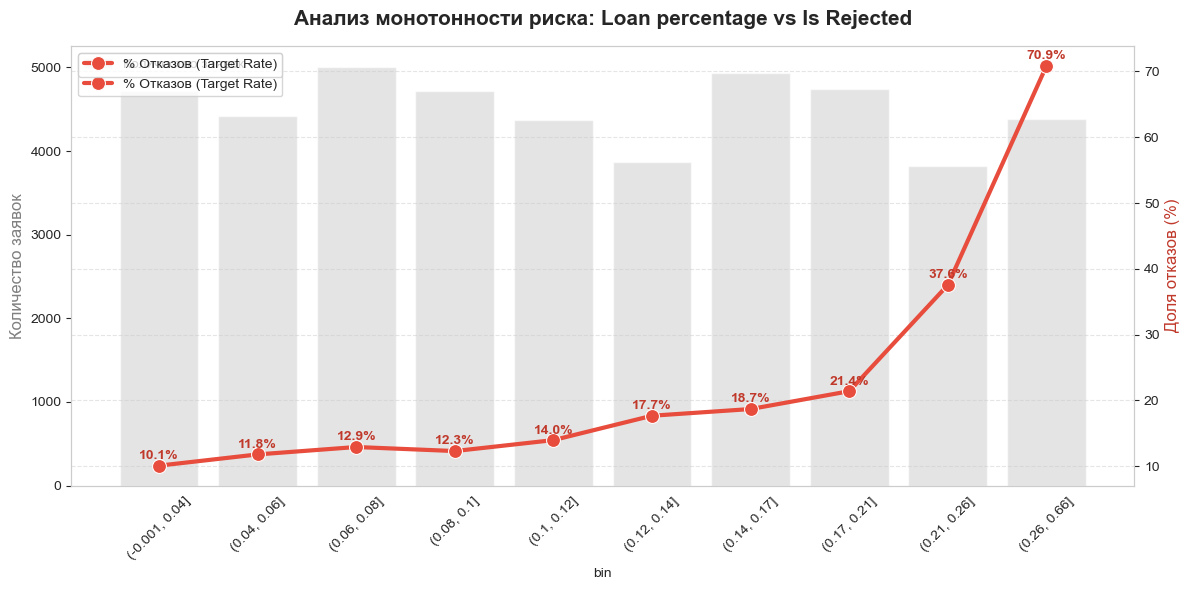

In [ ]:
plot_target_rate_by_bins(clean_df, "Loan percentage", bins=10)

> ### 📌 Target Rate by Bins: `Loan percentage`(Доля кредита от дохода)
>
> * **Анализ монотонности:** График демонстрирует ярко выраженный экспоненциальный рост доли отказов при переходе от меньших корзин к большим. Если на начальных децилях (до 10% от дохода) процент отказов минимален и составляет единицы процентов, то по мере роста коэффициента долговой нагрузки он начинает стремительно увеличиваться.
> * **Ключевой порог:** В районе 17-21% от дохода происходит резкий перелом тренда, а на верхних децилях (более 30% от дохода) Target Rate достигает пика, когда отказом заканчивается подавляющее большинство заявок. Это подтверждает монотонность связи и делает данный признак одним из сильнейших факторов в модели.

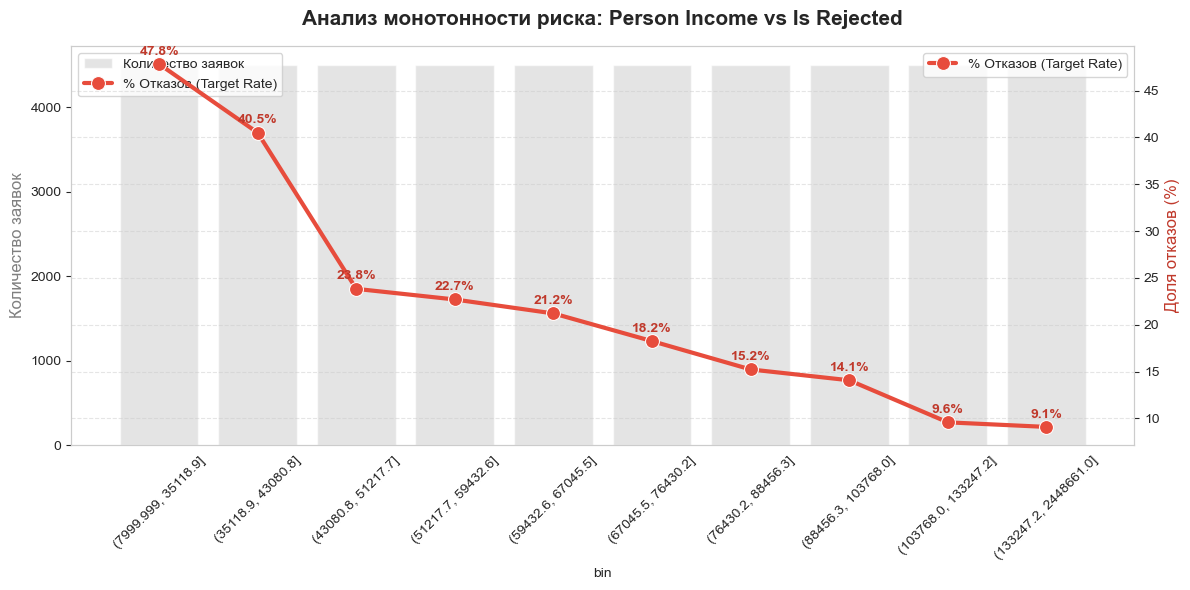

In [ ]:
plot_target_rate_by_bins(clean_df, "Person Income", bins=10)

> ### 📌 Target Rate by Bins: `Person Income`(Годовой доход)
>
> * **Анализ монотонности:** График демонстрирует четкую обратную монотонную связь со статусом кредита: по мере перехода от низких децилей дохода к высоким доля отказов плавно и непрерывно снижается.
> * **Ключевые зоны риска:** Максимальная концентрация отказов наблюдается в первых корзинах (доход ниже $8 000–$50 000), где риски банка наиболее велики. С ростом заработка уровень риска стабилизируется на низких значениях, подтверждая высокой статус дохода как одного из базовых предикторов надежности заёмщика.

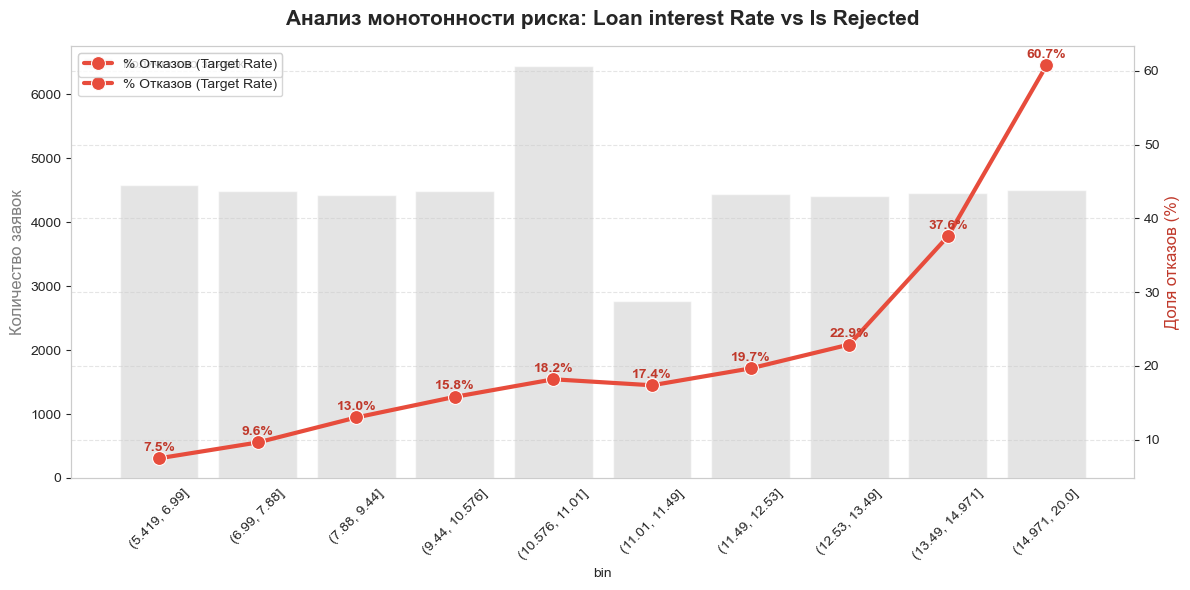

In [ ]:
plot_target_rate_by_bins(clean_df, "Loan interest Rate", bins=10)

> ### 📌 Target Rate by Bins: `Loan Interest Rate`(Процентная ставка)
>
> * **Анализ монотонности:** График показывает прямую экспоненциальную зависимость: с увеличением процентной ставки доля отказов растёт ускоряющимися темпами. В диапазоне минимальных ставок риски практически отсутствуют, тогда как в верхних децилях вероятность отказа становится преобладающей.
> * **Бизнес-контекст:** Такая динамика отражает риск-ориентированное ценообразование банка (Risk-Based Pricing). Высокaя ставка закладывается в договор изначально для компенсации риска проблемных клиентов, однако для большинства заёмщиков из этой группы она становится неподъёмной долговой нагрузкой, приводя к автоматическому отклонению заявки.

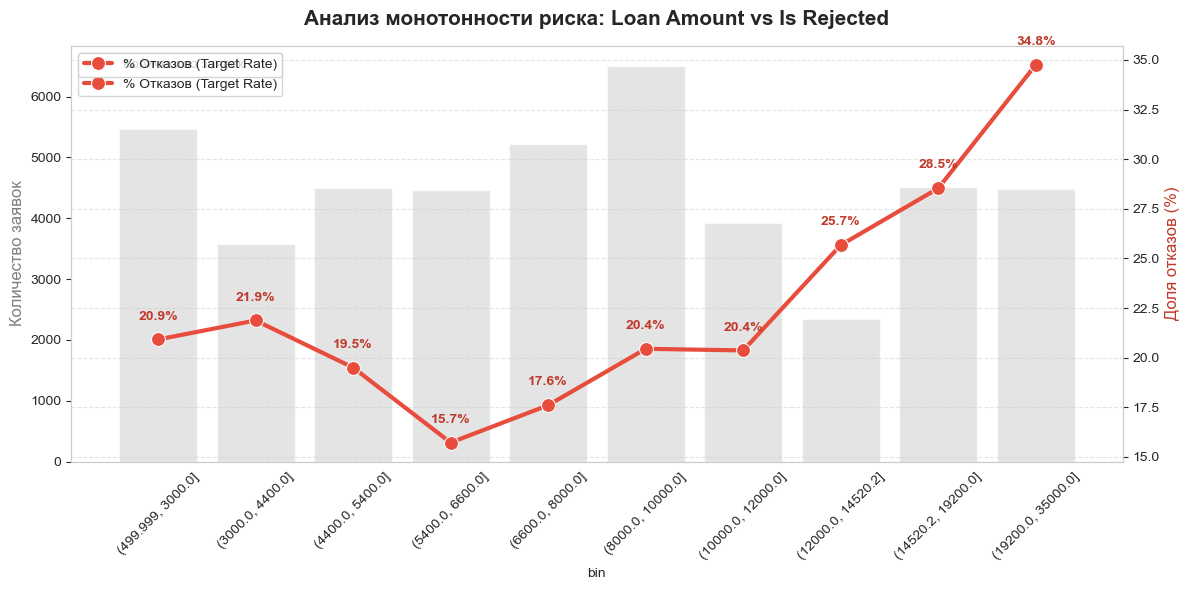

In [ ]:
plot_target_rate_by_bins(clean_df, "Loan Amount", bins=10)

> ### 📌 Target Rate by Bins: `Loan Amount` (Сумма кредита)
>
> * **Анализ монотонности:** График демонстрирует сложную, нелинейную динамику риска. На мелких суммах (до $5 000) доля отказов держится на базовом уровне ~20%, после чего в диапазоне $5 000–$8 000 наблюдается просадка риска до минимума в 15–16% (зона наилучшей конверсии).
> * **Рост риска на крупных суммах:** Начиная с $8 000, нелинейность сменяется устойчивым линейным трендом — с ростом размера кредита процент отказов непрерывно увеличивается. Подобный V-образный характер связи подчеркивает, что абсолютная сумма займа влияет на риск неоднородно, в отличие от долговой нагрузки.

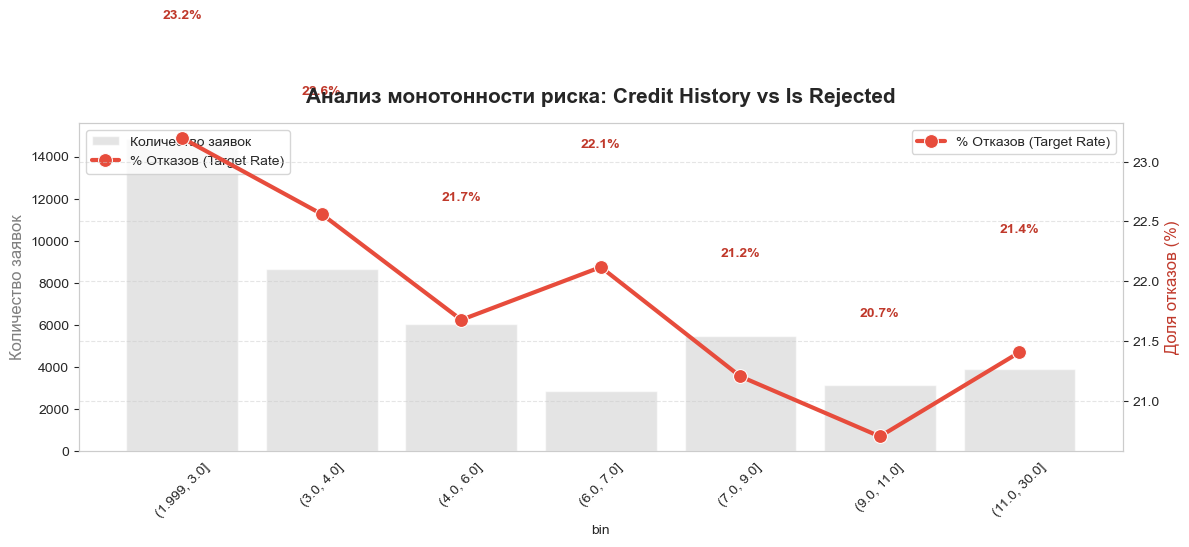

In [ ]:
plot_target_rate_by_bins(clean_df, "Credit History", bins=10)

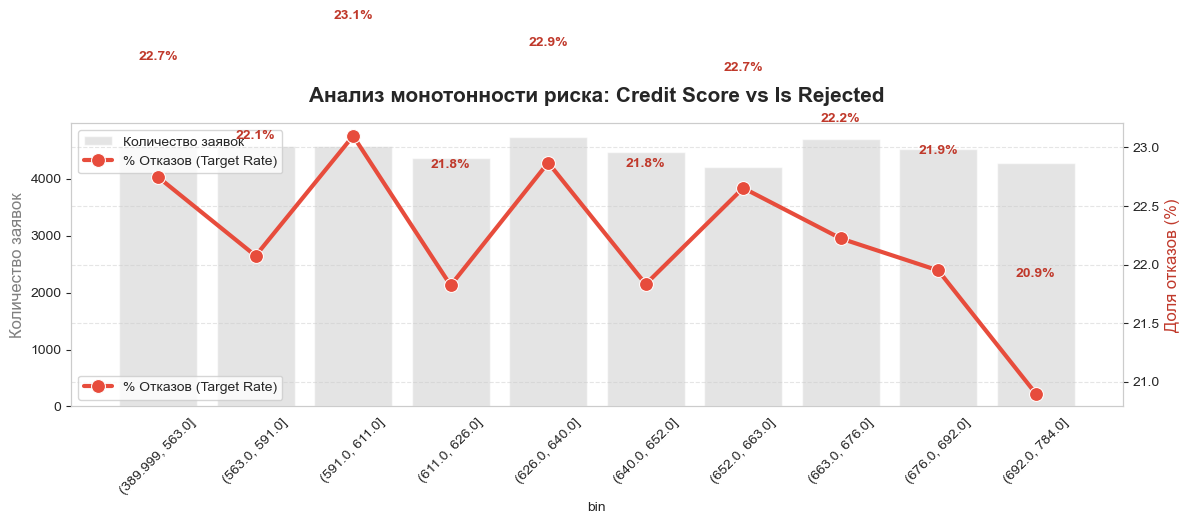

In [ ]:
plot_target_rate_by_bins(clean_df, "Credit Score", bins=10)

> ### 📌 Target Rate by Bins: `Credit History` и `Credit Score`
>
> * **Анализ монотонности:** Оба признака демонстрируют практически полное отсутствие выраженной монотонной связи с целевой переменной. На всём протяжении децилей (bins) процент отказов «болтается» на базовом уровне ~20% с несущественными колебаниями в пределах пару процентов.
> * **Бизнес-вывод:** Длительность кредитной истории и изолированный кредитный рейтинг в данном датасете не обеспечивают достаточной разделяющей силы (слабый изолированный сигнал). Они не могут использоваться как самостоятельные факторы принятия решений и будут иметь низкую индивидуальную значимость в модели.

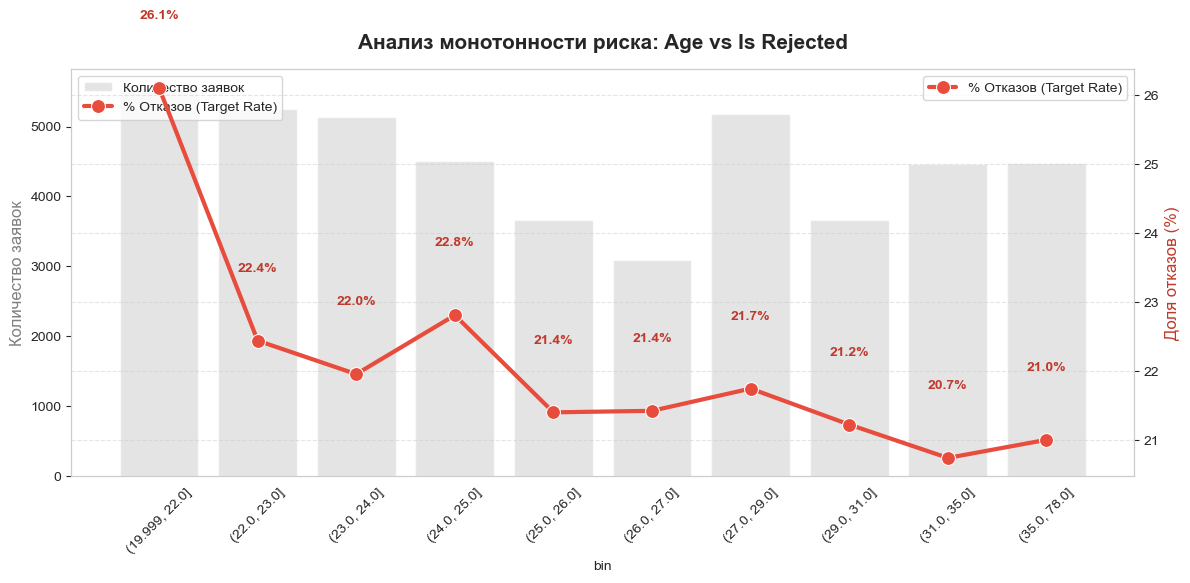

In [ ]:
plot_target_rate_by_bins(clean_df, "Age", bins=10)

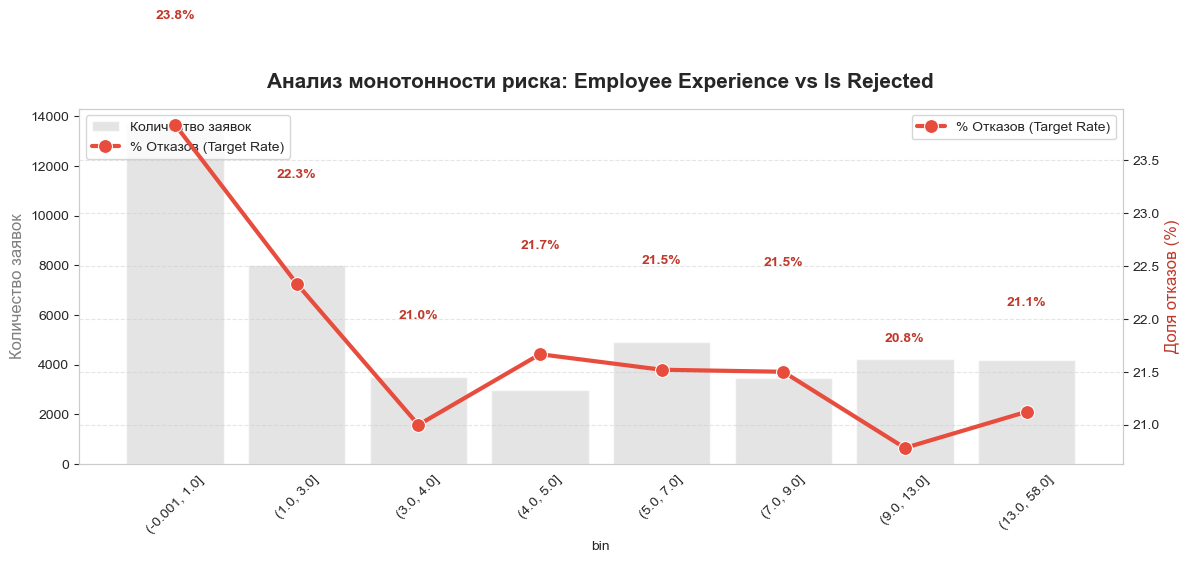

In [ ]:
plot_target_rate_by_bins(clean_df, "Employee Experience", bins=10)

> ### 📌 Target Rate by Bins: `Age` (Возраст) и `Employee Experience` (Стаж)
>
> * **Анализ монотонности:** Оба признака выказывают фоновый характер распределения риска. Небольшие локальные всплески наблюдаются только в группах с минимальным значением — для молодых клиентов (20–22 года) доля отказов возрастает до 26%, а для работников со стажем менее года — до 23%.
> * **Бизнес-вывод:** Для всех остальных возрастных категорий и уровней стажа показатель отказов стабильно фиксируется в районе ~20%. Подобная динамика указывает на слабую прямую линейную/монотонную связь: данные признаки вносят незначительный индивидуальный вклад (высокий уровень статистического «шума») и будут играть роль лишь в комбинациях с другими факторами.

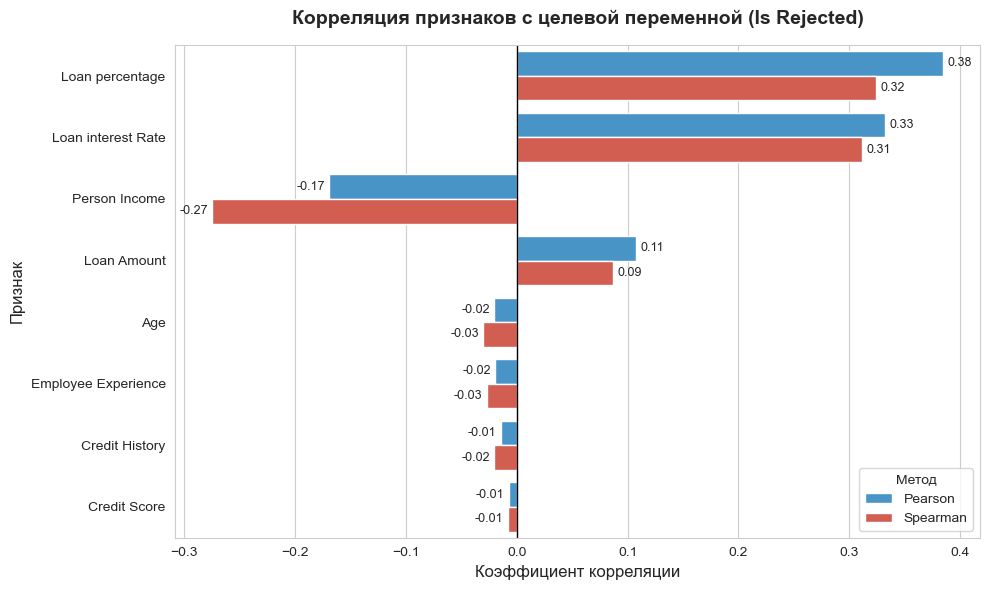

In [ ]:
plot_target_correlation(clean_df, target_col="Is Rejected")

> ### 📌 Корреляционный анализ относительно целевой переменной (`is_rejected`)
>
> * **Доминирующие предикторы (`Loan Percentage` и `Loan Interest Rate`):** Демонстрируют сильнейшую прямую связь с риском отказа ($r \approx +0.33 \dots +0.38$). Показатели Пирсона и Спирмена практически совпадают, подтверждая устойчивый рост вероятности отклонения заявки по мере увеличения долговой нагрузки и процентной ставки.
> * **Нелинейная монотонность (`Person Income`):** Имеет явную обратную корреляцию с отказом. Значение коэффициента Спирмена ($-0.27$) существенно превосходит Пирсона ($-0.17$). Более сильная по модулю корреляция Спирмена по сравнению с Пирсоном указывает на возможное наличие нелинейной монотонной зависимости. Деревья решений идеально обработают такую зависимость без дополнительных трансформаций.
> * **Слабые и изолированные факторы:** `Loan Amount` показывает лишь слабую положительную корреляцию ($\approx 0.09 \dots 0.11$). У признаков `Age`, `Employee Experience`, `Credit History` и `Credit Score` линейная и раcontent-связи с целевой переменной в изоляции практически отсутствуют ($\approx 0.01$), что полностью совпадает с результатами анализа по корзинам (Bins).

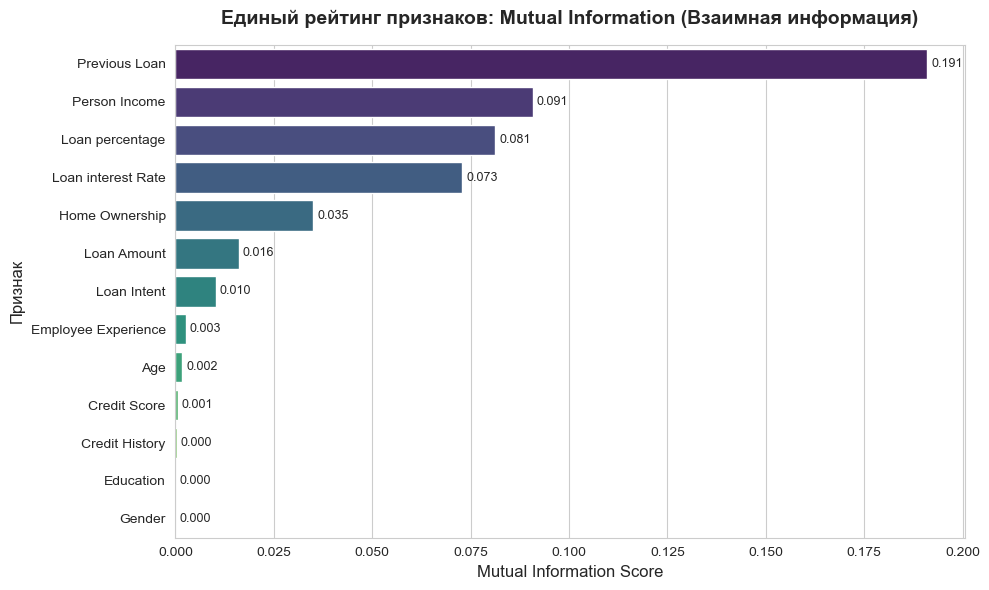

,Feature,MI_Score
0,Previous Loan,1.910331e-01
1,Person Income,9.079634e-02
2,Loan percentage,8.123493e-02
3,Loan interest Rate,7.292093e-02
4,Home Ownership,3.502114e-02
5,Loan Amount,1.608390e-02
6,Loan Intent,1.020519e-02
7,Employee Experience,2.593454e-03
8,Age,1.692238e-03
9,Credit Score,5.850666e-04


In [ ]:
plot_mutual_information(clean_df, target_col="Is Rejected")

> Показатель Mutual Information для previous_loan составляет 0.191 (объясняет ~36% энтропии таргета $H(Y) \approx 0.53$).В данных наблюдается 100% одобрение для подгруппы Previous Loan = Yes, что нереалистично для кредитного скоринга.

> Если оставить колонку какой она сейчас имеется, то модель отдаст этому признаку большую часть важности (Feature Importance) и перестанет анализировать доход, возраст, задолженность и стаж работы для 25 000 человек. На тестовых данных из этой же выборки метрики (Accuracy/ROC-AUC) будут очень высоки, но в реальном продакшене модель полностью провалится.

## Анализ и обработка аномального признака `Previous Loan`

### 1. Контекст и проблематика
В ходе исследования взаимосвязи признаков с целевой переменной `is_rejected` был выявлен аномальный характер переменной `Previous Loan`:
* **Детерминированный результат:** В подгруппе клиентов с `Previous Loan = Yes` (повторные обращения) зафиксирована **0% доля отказов** (100% одобрение).
* **Сверхвысокая взаимная информация:** Показатель Mutual Information составляет $MI \approx 0.191$ ната, что объясняет около **36% всей энтропии целевой переменной** ($H(Y) \approx 0.53$).

В реальной банковской практике наличие прошлых кредитов не гарантирует 100% одобрения без учёта текущего финансового состояния. Подобное распределение указывает на то, что признак является **синтетическим артефактом** или результатом работы жесткого бизнес-правила (Rule Engine), встроенного в процесс генерации данных.

---

### 2. Сравнительный анализ методологических подходов

Для определения стратегии подготовки данных к этапу моделирования были рассмотрены три сценария:

| Подход | Суть методологии | Плюсы | Минусы |
| :--- | :--- | :--- | :--- |
| **Подход 1: Использование признака «как есть»** | Обучение модели на полном датасете с сохранением колонки `Previous Loan`. | • Максимальные метрики качества ($AUC\text{-}ROC > 0.98$).<br>• Простота реализации. | • Искусственное завышение метрик за счёт одного правильного сплита (Data Leakage).<br>• Искажение Feature Importance для остальных признаков.<br>• Модель не учится оценивать финансовые риски. |
| **Подход 2: Исключение только колонки** | Удаление признака `Previous Loan` при сохранении всех строк в выборке. | • Сохранение максимального объёма данных (~45 000 наблюдений). | • Внесение сильного шума в целевую переменную (Label Noise).<br>• Модель выучит ложные финансовые паттерны, так как гарантированно одобренные клиенты с высокой долговой нагрузкой запутают алгоритм. |
| **Подход 3: Сегментация и двухэтапный скоринг (Выбран)** | Удаление колонки `Previous Loan` и фильтрация датасета (удаление наблюдений с `Previous Loan = Yes`). | • Полное устранение эффекта утечки данных.<br>• Модель фокусируется исключительно на выявлении реальных финансовых паттернов.<br>• Отражает реальную архитектуру банковского скоринга. | • Сокращение размера обучающей выборки до ~22 000 строк (что остаётся полностью достаточным для градиентного бустинга). |

---

### 3. Фиксация итогового решения

**Принято решение реализовать Подход №3 (Сегментация и двухэтапный скоринг).**

#### Обоснование решения:
1. **Бизнес-архитектура:** Процесс принятия решений разделяется на два уровня:
   * *Уровень 1 (Rule Engine):* Автоматическое одобрение категорий клиентов с безупречной историей повторных обращений без привлечения ML-модели.
   * *Уровень 2 (ML Scorecard):* Оценка риска с помощью ML-модели исключительно для категории первичных заявителей (`Previous Loan = No`), где требуется глубокая оценка кредитоспособности.
2. **Качество обучения:** Исключение детерминированной подвыборки позволяет очистить обучающий датасет от искажающих сигналов и заставляет модель находить физически обоснованные зависимости между доходом (`Person Income`), долговой нагрузкой (`Loan Percentage`), процентной ставкой (`Loan Interest Rate`) и риском дефолта.
3. **Репрезентативность:** Выборка в ~15 000+ наблюдений для первичных клиентов является репрезентативной и достаточной для устойчивого обучения алгоритмов классификации (Random Forest, LightGBM, XGBoost).

In [ ]:
# 1. Определяем название колонки
col_name = "Previous Loan"

# 2. Оставляем только первичных клиентов (где нет прошлых займов)
clean_df = clean_df[clean_df[col_name] == "No"].copy()

# 3. Удаляем ставшую константной колонку
clean_df = clean_df.drop(columns=[col_name])

# 4. Проверяем итоговую размерность датасета
print(
    f"Новый размер датасета для обучения: {clean_df.shape[0]} строк, {clean_df.shape[1]} колонок"
)

clean_df.info()

Новый размер датасета для обучения: 22135 строк, 13 колонок
<class 'pandas.core.frame.DataFrame'>
Index: 22135 entries, 0 to 44999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  22135 non-null  int64  
 1   Gender               22135 non-null  object 
 2   Education            22135 non-null  object 
 3   Person Income        22135 non-null  int64  
 4   Employee Experience  22135 non-null  int64  
 5   Home Ownership       22135 non-null  object 
 6   Loan Amount          22135 non-null  int64  
 7   Loan Intent          22135 non-null  object 
 8   Loan interest Rate   22135 non-null  float64
 9   Loan percentage      22135 non-null  float64
 10  Credit History       22135 non-null  int64  
 11  Credit Score         22135 non-null  int64  
 12  Is Rejected          22135 non-null  int64  
dtypes: float64(2), int64(7), object(4)
memory usage: 2.4+ MB


> ## Колонка `Previous Loan` и все строки у которых `Previous Loan == "Yes"` были удалены из датасета(очень важно!)

> **«Это решение не является универсальной рекомендацией для реального проекта. Оно принято именно для данного синтетического датасета из-за обнаруженной детерминированной зависимости `Previous Loan → Loan Status`. Для реального банковского проекта необходимо сначала проверить происхождение признака и бизнес-логику его формирования.»**

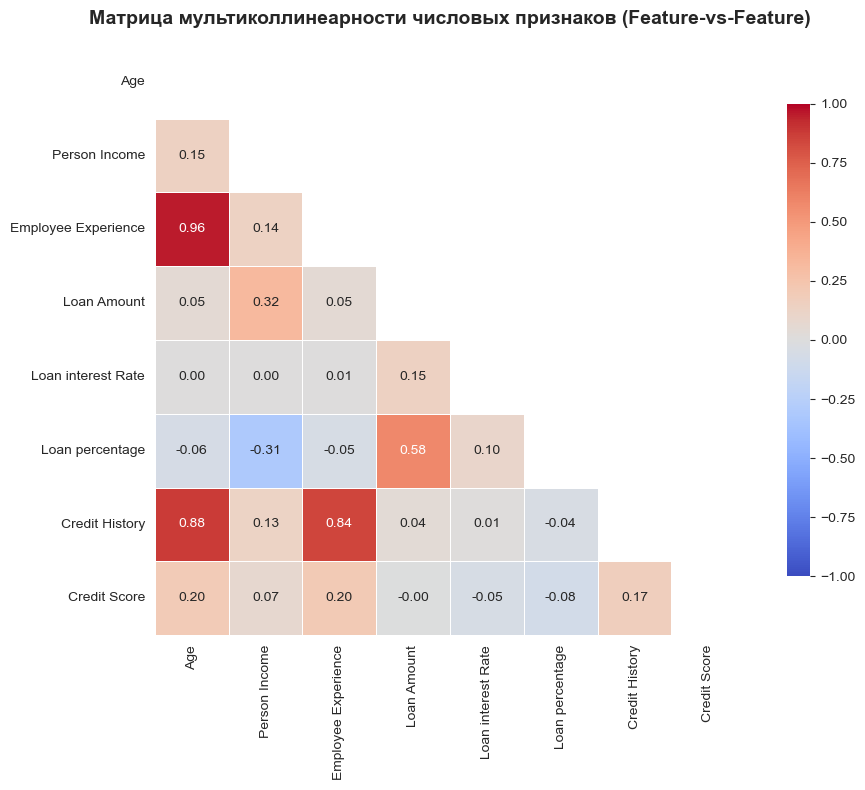

In [ ]:
plot_feature_correlation_heatmap(clean_df, target_col="Is Rejected")

> ### 📌 Анализ мультиколлинеарности числовых признаков (Feature-vs-Feature)
>
> Построенная матрица корреляций выявила две четкие группы взаимозависимых признаков, которые необходимо учесть при моделировании:
>
> **1. Критический «Временной кластер» (Мультиколлинеарность $> 0.80$):**
> * Выявлена экстремально сильная линейная связь между `Age` и `Employee Experience` (**0.95**), `Age` и `Credit History` (**0.88**), а также `Employee Experience` и `Credit History` (**0.84**). 
> * **Причина:** Естественное течение времени. С возрастом человека линейно увеличивается и его рабочий стаж, и длина кредитной истории. По сути, эти три признака передают модели одну и ту же информацию.
>
> **2. Умеренный «Финансовый треугольник» (Связь производных признаков):**
> * Наблюдается логичная корреляция между `Loan Percentage` и `Loan Amount` (**0.59**), а также их связь с `Person Income` (**0.31** и **-0.29** соответственно). 
> * **Причина:** Жесткая математическая зависимость, так как `Loan Percentage = Loan Amount / Person Income`.
>
> **🛠 Стратегия для ML-моделирования:**
> * **Для ансамблей на деревьях (LightGBM, Random Forest):** Оставляем все признаки. Деревья устойчивы к мультиколлинеарности и сами выберут наиболее информативный сплит.
> * **Для линейных моделей (Logistic Regression):** Из «временного кластера» необходимо оставить только один наиболее значимый признак (например, `Employee Experience`), а остальные удалить во избежание взрывного роста дисперсии весов (Dummy Variable Trap).

In [ ]:
# Сохраняем очищенный датасет
clean_df.to_csv("../data/clean_data.csv", index=False)
print("Очищенные данные успешно сохранены в data/clean_data.csv")

Очищенные данные успешно сохранены в data/clean_data.csv


# Итоговые выводы EDA

В ходе исследования был проведён полный первичный анализ датасета кредитных заявок: изучены структура и качество данных, распределения признаков, наличие аномальных значений, баланс целевой переменной, одномерные и двумерные зависимости, а также Mutual Information между признаками и target.

### 1. Качество данных

Исходный датасет содержит **45 000 наблюдений и 14 признаков**, пропущенные значения и полные дубликаты отсутствуют. Целевая переменная является бинарной и несбалансированной: около **77.8% заявок относятся к классу 0 и 22.2% — к классу 1**.

В исходных данных обнаружены физически неправдоподобные значения `Age` и `Employee Experience`. После фильтрации этих записей осталось **44 990 наблюдений**. Остальные экстремальные значения финансовых признаков были сохранены, поскольку сами по себе статистические выбросы не являются доказательством ошибки в данных.

### 2. Распределения признаков

Большинство числовых признаков имеют выраженную асимметрию и/или тяжёлые хвосты. Особенно это характерно для `Person Income`, `Age` и `Employee Experience`. Для `Person Income` наблюдается сильный правый хвост, поэтому при использовании линейных и других чувствительных к масштабу моделей в дальнейшем может быть полезно рассмотреть логарифмическое преобразование.

`Loan Amount` имеет выраженную полимодальную структуру с пиками на типичных «круглых» значениях, а `Loan interest Rate` и `Loan percentage` демонстрируют наиболее заметную связь с вероятностью отказа.

### 3. Связь признаков с целевой переменной

Наиболее выраженные одномерные зависимости с `Is Rejected` наблюдаются у:

* `Previous Loan`;
* `Person Income`;
* `Loan percentage`;
* `Loan interest Rate`;
* `Home Ownership`;
* `Loan Intent`.

При этом `Age`, `Employee Experience`, `Credit History` и `Credit Score` не демонстрируют сильной монотонной зависимости с target в изоляции. Это не означает, что они обязательно бесполезны для ML-модели: их вклад может проявляться через нелинейные зависимости и взаимодействия с другими признаками.

`Gender` и `Education` также не показывают выраженной одномерной зависимости с target и поэтому требуют дополнительной проверки уже на этапе моделирования, прежде чем принимать решение об их окончательном удалении.

### 4. Ключевая проблема — `Previous Loan`

Наиболее важным результатом EDA стало обнаружение аномальной зависимости между `Previous Loan` и `Is Rejected`.

Для клиентов с `Previous Loan = Yes` доля одобрений составляет **100%**, тогда как для `Previous Loan = No` доля отказов составляет около **45%**. Mutual Information этого признака с target существенно выше, чем у остальных признаков.

Такая детерминированная зависимость может указывать на target leakage, proxy-признак либо на наличие встроенного бизнес-правила/артефакта генерации синтетического датасета.

Поэтому использовать `Previous Loan` как обычный ML-признак некорректно без дополнительного понимания происхождения этой зависимости.

### 5. Решение для дальнейшего моделирования

Для данного синтетического датасета принято решение рассматривать клиентов с `Previous Loan = Yes` как отдельный rule-based сегмент и обучать ML-модель только на клиентах с `Previous Loan = No`.

После фильтрации размер обучающей выборки составляет **22 135 наблюдений**, а сам признак `Previous Loan` удаляется, поскольку после фильтрации становится константным.

В дальнейшем **ML-модель** будет обучена на основе финансовых и демографических характеристик заемщиков.

Важно отметить, что данное решение является специфичным для исследуемого синтетического датасета. Для реального банковского проекта перед удалением признака необходимо установить происхождение `Previous Loan` и подтвердить бизнес-логику, которая формирует его связь с целевой переменной.

### 6. Итог

EDA позволил не только оценить качество и структуру данных, но и выявить потенциально критическую проблему в постановке задачи — детерминированную связь `Previous Loan` с целевой переменной.

После устранения физических аномалий и выделения проблемного сегмента данные готовы к следующему этапу: **подготовке признаков, train/validation split, построению baseline-модели и последующему сравнению ML-алгоритмов по подходящим метрикам с учётом дисбаланса классов**.
